# Anomaly Detection in Time Series Data

Anomaly detection is the process of identifying data points or patterns in a dataset that deviate significantly from the norm. A time series is a collection of data points gathered over some time. Anomaly detection in time series data may be helpful in various industries, including manufacturing, healthcare, and finance. Anomaly detection in time series data may be accomplished using unsupervised learning approaches like clustering, PCA (Principal Component Analysis), and autoencoders.

## What is an Anomaly Detection Algorithm?
Anomaly detection is the process of identifying data points that deviate from the expected patterns in a dataset. Many applications, including fraud detection, intrusion detection, and failure detection, often use anomaly detection techniques. Finding uncommon or very infrequent events that could point to a possible hazard, issue, or opportunity is the aim of anomaly detection.

The autoencoder algorithm is an unsupervised deep learning algorithm that can be used for anomaly detection in time series data. The autoencoder is a neural network that learns to reconstruct its input data By first compressing input data into a lower-dimensional representation and then extending it back to its original dimensions. An autoencoder may be trained on typical time series data to learn a compressed version of the data for anomaly identification. The anomaly score may then be calculated using the reconstruction error between the original and reconstructed data. Anomalies are data points with considerable reconstruction errors.

Time Series Data and Anamoly Detection
In the case of time series data, anomaly detection algorithms are especially important since they help us spot odd patterns in the data that would not be obvious from just looking at the raw data. Anomalies in time series data might appear as abrupt increases or decrease in values, odd patterns, or unexpected seasonality. Time series data is a collection of observations across time.

* Time series data may be used to teach anomaly detection algorithms, such as the autoencoder, how to represent typical patterns. These algorithms can then utilize this representation to find anomalies. The approach can learn a compressed version of the data by training an autoencoder on regular time series data. The anomaly score may then be calculated using the reconstruction error between the original and reconstructed data. Anomalies are data points with considerable reconstruction errors.

* Anomaly detection algorithms may be applied to time series data to find odd patterns that could point to a hazard, issue, or opportunity. For instance, in the context of predictive maintenance, a time series anomaly may point to a prospective equipment failure that may be fixed before it results in a large amount of downtime or safety concerns. Anomalies in time series data may reveal market movements or patterns in financial forecasts that may be capitalized on.

The reason for getting precision, recall, and F1 score of 1.0 is that the "ambient_temperature_system_failure.csv" dataset from the NAB repository contains anomalies. If we had gotten precision, recall, and F1 score of 0.0, then that means the "ambient_temperature_system_failure.csv" dataset from the NAB repository does not contain anomalies.

## Importing Libraries and Dataset
Python libraries make it very easy for us to handle the data and perform typical and complex tasks with a single line of code.

* Pandas – This library helps to load the data frame in a 2D array format and has multiple functions to perform analysis tasks in one go.
* Numpy – Numpy arrays are very fast and can perform large computations in a very short time.
* Matplotlib/Seaborn – This library is used to draw visualizations.
* Sklearn – This module contains multiple libraries having pre-implemented functions to perform tasks from data preprocessing to model development and evaluation.
* TensorFlow – This is an open-source library that is used for Machine Learning and Artificial intelligence and provides a range of functions to achieve complex functionalities with single lines of code.

In [1]:
import pandas as pd
import tensorflow as tf
from keras.layers import Input, Dense
from keras.models import Model
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt

d:\mini projects\projects\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In this step, we import the libraries required for the implementation of the anomaly detection algorithm using an autoencoder. We import pandas for reading and manipulating the dataset, TensorFlow and Keras for building the autoencoder model, and scikit-learn for calculating the precision, recall, and F1 score.

In [2]:
data = pd.read_csv(
    'ambient_temperature_system_failure.csv')

# Exclude datetime column
data_values = data.drop('timestamp',
                        axis=1).values

# Convert data to float type
data_values = data_values.astype('float32')

# Create new dataframe with converted values
data_converted = pd.DataFrame(data_values,
                              columns=data.columns[1:])

# Add back datetime column
data_converted.insert(0, 'timestamp',
                      data['timestamp'])

We load a dataset called "ambient_temperature_system_failure.csv" from the Numenta Anomaly Benchmark (NAB) dataset, which contains time-series data of ambient temperature readings from a system that experienced a failure. 

The panda's library is used to read the CSV file from a remote location on GitHub and store it in a variable called "data".

* Now, the code drops the "timestamp" column from the "data" variable, since it is not needed for data analysis purposes. The remaining columns are stored in a variable called "data_values".
* Then, the "data_values" are converted to the "float32" data type to reduce memory usage, and a new pandas DataFrame called "data_converted" is created with the converted data. The columns of "data_converted" are labeled with the original column names from "data", except for the "timestamp" column that was previously dropped.
* Finally, the code adds the "timestamp" column back to "data_converted" at the beginning using the "insert()" method. The resulting DataFrame "data_converted" has the same data as "data" but without the unnecessary "timestamp" column, and the data is in a format that can be used for analysis and visualization.

In [3]:
data_converted = data_converted.dropna()

We remove any missing or NaN values from the dataset.

## Anomaly Detection using Autoencoder
It is a type of neural network that learns to compress and then reconstruct the original data, allowing it to identify anomalies in the data.

In [4]:
# Exclude datetime column again
data_tensor = tf.convert_to_tensor(data_converted.drop(
    'timestamp', axis=1).values, dtype=tf.float32)

# Define the autoencoder model
input_dim = data_converted.shape[1] - 1
encoding_dim = 10

input_layer = Input(shape=(input_dim,))
encoder = Dense(encoding_dim, activation='relu')(input_layer)
decoder = Dense(input_dim, activation='relu')(encoder)
autoencoder = Model(inputs=input_layer, outputs=decoder)

# Compile and fit the model
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(data_tensor, data_tensor, epochs=50,
                batch_size=32, shuffle=True)

# Calculate the reconstruction error for each data point
reconstructions = autoencoder.predict(data_tensor)
mse = tf.reduce_mean(tf.square(data_tensor - reconstructions),
                     axis=1)
anomaly_scores = pd.Series(mse.numpy(), name='anomaly_scores')
anomaly_scores.index = data_converted.index

Epoch 1/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 5093.5220
Epoch 2/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5093.5215
Epoch 3/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5093.5234
Epoch 4/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5093.5249
Epoch 5/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5093.5229
Epoch 6/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5093.5225
Epoch 7/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5093.5225
Epoch 8/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5093.5229
Epoch 9/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5093.5229
Epoch 10/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5093.5229
Epoch 11/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5093.5220
Epoch 12/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5093.5234
Epoch 13/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5093.5215
Epoch 14/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5093.5220
Epoch 15/50
228

We define the autoencoder model and fit it to the cleaned data. The autoencoder is used to identify any deviations from the regular patterns in the data that are learned from the data. To reduce the mean squared error between the input and the output, the model is trained. The reconstruction error for each data point is determined using the trained model and is utilized as an anomaly score.

In [5]:
threshold = anomaly_scores.quantile(0.99)
anomalous = anomaly_scores > threshold
binary_labels = anomalous.astype(int)
precision, recall,\
    f1_score, _ = precision_recall_fscore_support(
        binary_labels, anomalous, average='binary')

Here, we define an anomaly detection threshold and assess the model's effectiveness using precision, recall, and F1 score. Recall is the ratio of true positives to all real positives, whereas precision is the ratio of genuine positives to all projected positives. The harmonic mean of recall and accuracy is the F1 score.

In [6]:
test = data_converted['value'].values
predictions = anomaly_scores.values

print("Precision: ", precision)
print("Recall: ", recall)
print("F1 Score: ", f1_score)

Precision:  1.0
Recall:  1.0
F1 Score:  1.0


## Visualizing the Anomaly
Now let's plot the anomalies which are predicted by the model and get a feel for whether the predictions made are correct or not by plotting the anomalous examples with red marks with the complete data.

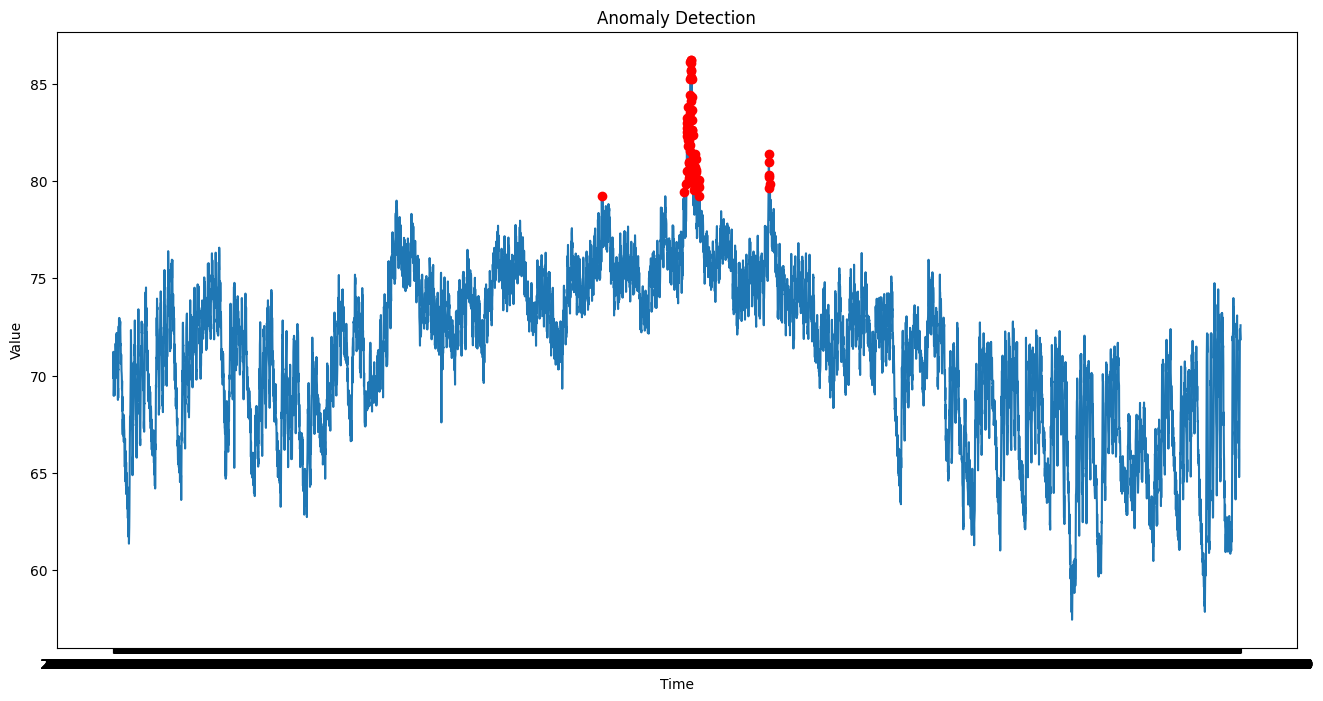

In [7]:
# Plot the data with anomalies marked in red
plt.figure(figsize=(16, 8))
plt.plot(data_converted['timestamp'],
         data_converted['value'])
plt.plot(data_converted['timestamp'][anomalous],
         data_converted['value'][anomalous], 'ro')
plt.title('Anomaly Detection')
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()